In [ ]:
# Import library:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from google.colab import files
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [ ]:
# kiểm tra file
os.listdir()

['.config',
 'sales.csv',
 'order_items.csv',
 'web_traffic.csv',
 'promotions.csv',
 'payments.csv',
 'sample_submission.csv',
 'geography.csv',
 'reviews.csv',
 'customers.csv',
 'inventory.csv',
 'returns.csv',
 'shipments.csv',
 'products.csv',
 'orders.csv',
 'sample_data']

In [ ]:
# Load file vào pandas
sales = pd.read_csv('sales.csv')
promotions = pd.read_csv('promotions.csv')
products = pd.read_csv('products.csv')
geography = pd.read_csv('geography.csv')
returns = pd.read_csv('returns.csv')
web_traffic = pd.read_csv('web_traffic.csv')
inventory = pd.read_csv('inventory.csv')
reviews = pd.read_csv('reviews.csv')
customers = pd.read_csv('customers.csv')
payments = pd.read_csv('payments.csv')
shipments = pd.read_csv('shipments.csv')
order_items = pd.read_csv('order_items.csv')
orders = pd.read_csv('orders.csv')
sample_submission = pd.read_csv('sample_submission.csv')

/tmp/ipykernel_4623/3294821587.py:13: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  order_items = pd.read_csv('order_items.csv')


In [ ]:
# File Dictionary
dfs = {
    'sales': sales,
    'promotions': promotions,
    'products': products,
    'geography': geography,
    'returns': returns,
    'web_traffic': web_traffic,
    'inventory': inventory,
    'reviews': reviews,
    'customers': customers,
    'payments': payments,
    'shipments': shipments,
    'order_items': order_items,
    'orders': orders,
    'sample_submission': sample_submission
}

In [ ]:
# Check shape các file:
for name, df in dfs.items():
    print(f'{name}: {df.shape}')

sales: (3833, 3)
promotions: (50, 10)
products: (2412, 8)
geography: (39948, 4)
returns: (39939, 7)
web_traffic: (3652, 7)
inventory: (60247, 17)
reviews: (113551, 7)
customers: (121930, 7)
payments: (646945, 4)
shipments: (566067, 4)
order_items: (714669, 7)
orders: (646945, 8)
sample_submission: (548, 3)


In [ ]:
# Check giá trị đầu
for name, df in dfs.items():
    print(f'\n===== {name.upper()} =====')
    display(df.head())


===== SALES =====


,Date,Revenue,COGS
0,2012-07-04,5123547.94,3982991.19
1,2012-07-05,2751773.45,2150580.23
2,2012-07-06,3054029.42,2517632.84
3,2012-07-07,2667930.94,2108246.62
4,2012-07-08,2360851.90,1808622.79



===== PROMOTIONS =====


,promo_id,promo_name,promo_type,discount_value,start_date,end_date,applicable_category,promo_channel,stackable_flag,min_order_value
0,PROMO-0001,Spring Sale 2013,percentage,12.0,2013-03-18,2013-04-17,NaN,email,1,0
1,PROMO-0002,Mid-Year Sale 2013,percentage,18.0,2013-06-23,2013-07-22,NaN,online,0,0
2,PROMO-0003,Fall Launch 2013,percentage,10.0,2013-08-30,2013-10-02,NaN,email,0,0
3,PROMO-0004,Year-End Sale 2013,percentage,20.0,2013-11-18,2014-01-02,NaN,all_channels,0,50000
4,PROMO-0005,Urban Blowout 2013,fixed,50.0,2013-07-30,2013-09-02,Streetwear,online,0,150000



===== PRODUCTS =====


...

,order_id,product_id,quantity,unit_price,discount_amount,promo_id,promo_id_2
0,1,2400,7,1138.22,0.0,NaN,NaN
1,2,609,7,10166.25,0.0,NaN,NaN
2,3,396,3,11220.33,0.0,NaN,NaN
3,4,635,5,10639.25,0.0,NaN,NaN
4,6,1935,1,1597.84,0.0,NaN,NaN



===== ORDERS =====


,order_id,order_date,customer_id,zip,order_status,payment_method,device_type,order_source
0,1,2012-07-04,58578,1109,delivered,credit_card,desktop,paid_search
1,2,2012-07-04,58621,1330,returned,cod,mobile,paid_search
2,3,2012-07-04,58811,1473,delivered,credit_card,desktop,direct
3,4,2012-07-04,59453,2360,delivered,credit_card,desktop,referral
4,6,2012-07-06,57821,2886,delivered,paypal,mobile,email_campaign



===== SAMPLE_SUBMISSION =====


,Date,Revenue,COGS
0,2023-01-01,2665507.20,2518885.15
1,2023-01-02,1280007.89,1136463.00
2,2023-01-03,1015899.51,822721.12
3,2023-01-04,1142997.27,914554.18
4,2023-01-05,1236312.34,984390.24


In [ ]:
import sys
if 'google.colab' in sys.modules:
  %pip install ydata-profiling
from ydata_profiling import ProfileReport

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 61.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 33.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 4.9 MB/s eta 0:00:00


/tmp/ipykernel_4623/2537273131.py:4: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


In [ ]:
# brief EDA:

for name, df in dfs.items():
    if name != 'sample_submission':
        print(f"Generating ProfileReport for {name}...")
        profile = ProfileReport(df, title=f"{name.capitalize()} Report")
        profile.to_file(f"{name}_report.html")
        print(f"Report for {name} saved to {name}_report.html")

Generating ProfileReport for sales...


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 3/3 [00:00<00:00, 44.48it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

...


100%|██████████| 8/8 [00:06<00:00,  1.32it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Report for orders saved to orders_report.html


In [ ]:
# ktra Column name:
for name, df in dfs.items():
    print(f'\n===== {name.upper()} =====')
    print(df.columns.tolist())


===== SALES =====
['Date', 'Revenue', 'COGS']

===== PROMOTIONS =====
['promo_id', 'promo_name', 'promo_type', 'discount_value', 'start_date', 'end_date', 'applicable_category', 'promo_channel', 'stackable_flag', 'min_order_value']

===== PRODUCTS =====
['product_id', 'product_name', 'category', 'segment', 'size', 'color', 'price', 'cogs']

===== GEOGRAPHY =====
['zip', 'city', 'region', 'district']

===== RETURNS =====
['return_id', 'order_id', 'product_id', 'return_date', 'return_reason', 'return_quantity', 'refund_amount']

===== WEB_TRAFFIC =====
['date', 'sessions', 'unique_visitors', 'page_views', 'bounce_rate', 'avg_session_duration_sec', 'traffic_source']

===== INVENTORY =====
['snapshot_date', 'product_id', 'stock_on_hand', 'units_received', 'units_sold', 'stockout_days', 'days_of_supply', 'fill_rate', 'stockout_flag', 'overstock_flag', 'reorder_flag', 'sell_through_rate', 'product_name', 'category', 'segment', 'year', 'month']

===== REVIEWS =====
['review_id', 'order_id', 

In [ ]:
# Check thông tin từng bảng
for name, df in dfs.items():
    print(f'\n===== {name.upper()} =====')
    print(df.info())


===== SALES =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3833 entries, 0 to 3832
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     3833 non-null   object 
 1   Revenue  3833 non-null   float64
 2   COGS     3833 non-null   float64
dtypes: float64(2), object(1)
memory usage: 90.0+ KB
None

===== PROMOTIONS =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   promo_id             50 non-null     object 
 1   promo_name           50 non-null     object 
 2   promo_type           50 non-null     object 
 3   discount_value       50 non-null     float64
 4   start_date           50 non-null     object 
 5   end_date             50 non-null     object 
 6   applicable_category  10 non-null     object 
 7   promo_channel        50 non-null     object 


In [ ]:
# Check missing value
for name, df in dfs.items():
    print(f'\n===== {name.upper()} =====')
    missing = df.isnull().sum()
    missing = missing[missing > 0].sort_values(ascending=False)
    if len(missing) == 0:
        print('No missing values')
    else:
        print(missing)


===== SALES =====
No missing values

===== PROMOTIONS =====
applicable_category    40
dtype: int64

===== PRODUCTS =====
No missing values

===== GEOGRAPHY =====
No missing values

===== RETURNS =====
No missing values

===== WEB_TRAFFIC =====
No missing values

===== INVENTORY =====
No missing values

===== REVIEWS =====
No missing values

===== CUSTOMERS =====
No missing values

===== PAYMENTS =====
No missing values

===== SHIPMENTS =====
No missing values

===== ORDER_ITEMS =====
promo_id_2    714463
promo_id      438353
dtype: int64

===== ORDERS =====
No missing values

===== SAMPLE_SUBMISSION =====
No missing values


In [ ]:
# Check dupl
for name, df in dfs.items():
    dup_count = df.duplicated().sum()
    print(f'{name}: duplicated rows = {dup_count}')

sales: duplicated rows = 0
promotions: duplicated rows = 0
products: duplicated rows = 0
geography: duplicated rows = 0
returns: duplicated rows = 0
web_traffic: duplicated rows = 0
inventory: duplicated rows = 0
reviews: duplicated rows = 0
customers: duplicated rows = 0
payments: duplicated rows = 0
shipments: duplicated rows = 0
order_items: duplicated rows = 0
orders: duplicated rows = 0
sample_submission: duplicated rows = 0


In [ ]:
# Basic Statistic:
for name, df in dfs.items():
    print(f'\n===== {name.upper()} =====')
    display(df.describe(include=[np.number]))


===== SALES =====


,Revenue,COGS
count,3.833000e+03,3.833000e+03
mean,4.286584e+06,3.695134e+06
std,2.624840e+06,2.219789e+06
min,2.798139e+05,2.365763e+05
25%,2.471089e+06,2.150580e+06
50%,3.647304e+06,3.161113e+06
75%,5.350877e+06,4.637294e+06
max,2.090527e+07,1.653586e+07



===== PROMOTIONS =====


,discount_value,stackable_flag,min_order_value
count,50.000000,50.000000,50.000000
mean,18.500000,0.240000,46000.000000
std,11.241777,0.431419,66116.779802
min,10.000000,0.000000,0.000000
25%,12.000000,0.000000,0.000000
50%,16.500000,0.000000,0.000000
75%,20.000000,0.000000,100000.000000
max,50.000000,1.000000,200000.000000



===== PRODUCTS =====


...

,order_id,product_id,quantity,unit_price,discount_amount
count,714669.000000,714669.000000,714669.000000,714669.000000,714669.000000
mean,411615.076561,1234.931370,4.495988,5114.690157,1048.887415
std,240480.310686,691.332564,2.290143,3774.817912,2280.530606
min,1.000000,1.000000,1.000000,392.570000,0.000000
25%,203229.000000,689.000000,2.000000,1906.890000,0.000000
50%,409306.000000,990.000000,4.000000,4257.770000,0.000000
75%,618981.000000,2045.000000,6.000000,7273.760000,967.630000
max,834397.000000,2412.000000,8.000000,43056.000000,35235.470000



===== ORDERS =====


,order_id,customer_id,zip
count,646945.000000,646945.000000,646945.000000
mean,417189.470332,84906.203535,55410.740423
std,240785.704463,48446.922752,28876.471824
min,1.000000,1.000000,1001.000000
25%,208728.000000,41336.000000,30904.000000
50%,417211.000000,87279.000000,54129.000000
75%,625628.000000,133282.000000,83301.000000
max,834397.000000,157563.000000,99950.000000



===== SAMPLE_SUBMISSION =====


,Revenue,COGS
count,5.480000e+02,5.480000e+02
mean,3.249795e+06,2.783810e+06
std,1.581698e+06,1.360346e+06
min,9.773328e+05,7.902589e+05
25%,2.032802e+06,1.706747e+06
50%,2.968953e+06,2.575698e+06
75%,4.182023e+06,3.515931e+06
max,9.283417e+06,8.341542e+06


In [ ]:
# Check thống kê các object/categorical
for name, df in dfs.items():
    print(f'\n===== {name.upper()} =====')
    display(df.describe(include=['object']))


===== SALES =====


,Date
count,3833
unique,3833
top,2022-12-31
freq,1



===== PROMOTIONS =====


,promo_id,promo_name,promo_type,start_date,end_date,applicable_category,promo_channel
count,50,50,50,50,50,10,50
unique,50,50,2,50,50,2,5
top,PROMO-0001,Spring Sale 2013,percentage,2013-03-18,2013-04-17,Streetwear,all_channels
freq,1,1,45,1,1,5,19



===== PRODUCTS =====


...

,promo_id,promo_id_2
count,276316,206
unique,50,2
top,PROMO-0014,PROMO-0015
freq,11451,132



===== ORDERS =====


,order_date,order_status,payment_method,device_type,order_source
count,646945,646945,646945,646945,646945
unique,3833,6,5,3,6
top,2018-05-30,delivered,credit_card,mobile,organic_search
freq,803,516716,356352,291482,181495



===== SAMPLE_SUBMISSION =====


,Date
count,548
unique,548
top,2024-07-01
freq,1


In [ ]:
# Check date time:
for name, df in dfs.items():
    possible_date_cols = [col for col in df.columns if 'date' in col.lower() or 'time' in col.lower()]
    print(f'{name}: {possible_date_cols}')

sales: ['Date']
promotions: ['start_date', 'end_date']
products: []
geography: []
returns: ['return_date']
web_traffic: ['date']
inventory: ['snapshot_date']
reviews: ['review_date']
customers: ['signup_date']
payments: []
shipments: ['ship_date', 'delivery_date']
order_items: []
orders: ['order_date']
sample_submission: ['Date']


In [ ]:
# Quick capture:
audit_rows = []

for name, df in dfs.items():
    audit_rows.append({
        'table_name': name,
        'n_rows': df.shape[0],
        'n_cols': df.shape[1],
        'total_missing': int(df.isnull().sum().sum()),
        'duplicate_rows': int(df.duplicated().sum()),
        'possible_date_cols': [col for col in df.columns if 'date' in col.lower() or 'time' in col.lower()]
    })

audit_df = pd.DataFrame(audit_rows)
display(audit_df)

,table_name,n_rows,n_cols,total_missing,duplicate_rows,possible_date_cols
0,sales,3833,3,0,0,[Date]
1,promotions,50,10,40,0,"[start_date, end_date]"
2,products,2412,8,0,0,[]
3,geography,39948,4,0,0,[]
4,returns,39939,7,0,0,[return_date]
5,web_traffic,3652,7,0,0,[date]
6,inventory,60247,17,0,0,[snapshot_date]
7,reviews,113551,7,0,0,[review_date]
8,customers,121930,7,0,0,[signup_date]
9,payments,646945,4,0,0,[]


In [ ]:
# check kĩ lại bảng sales
display(sales.head())
display(sales.info())
display(sales.isnull().sum())
display(sales.describe(include='all'))

In [ ]:
# check lại để bản submit đều ổn
display(sample_submission.head())
display(sample_submission.info())
display(sample_submission.isnull().sum())
display(sample_submission.describe(include='all'))

In [ ]:
# parse lại date
for name, df in dfs.items():
    date_cols = [col for col in df.columns if 'date' in col or 'time' in col]
    for col in date_cols:
        dfs[name][col] = pd.to_datetime(dfs[name][col], errors='coerce')

In [ ]:
for name, df in dfs.items():
    date_cols = [col for col in df.columns if 'date' in col or 'time' in col]
    if date_cols:
        print(f'\n{name}:')
        print(df[date_cols].dtypes)


promotions:
start_date    datetime64[ns]
end_date      datetime64[ns]
dtype: object

returns:
return_date    datetime64[ns]
dtype: object

web_traffic:
date    datetime64[ns]
dtype: object

inventory:
snapshot_date    datetime64[ns]
dtype: object

reviews:
review_date    datetime64[ns]
dtype: object

customers:
signup_date    datetime64[ns]
dtype: object

shipments:
ship_date        datetime64[ns]
delivery_date    datetime64[ns]
dtype: object

orders:
order_date    datetime64[ns]
dtype: object


In [ ]:
# Xóa duplicate:
for name in dfs:
    before = dfs[name].shape[0]
    dfs[name] = dfs[name].drop_duplicates()
    after = dfs[name].shape[0]
    if before != after:
        print(f'{name}: removed {before - after} duplicate rows')

In [ ]:
# Check lại missing sau khi parse date:
for name, df in dfs.items():
    missing = df.isnull().sum()
    missing = missing[missing > 0].sort_values(ascending=False)
    print(f'\n===== {name.upper()} =====')
    if len(missing) == 0:
        print('No missing values')
    else:
        print(missing)


===== SALES =====
No missing values

===== PROMOTIONS =====
applicable_category    40
dtype: int64

===== PRODUCTS =====
No missing values

===== GEOGRAPHY =====
No missing values

===== RETURNS =====
No missing values

===== WEB_TRAFFIC =====
No missing values

===== INVENTORY =====
No missing values

===== REVIEWS =====
No missing values

===== CUSTOMERS =====
No missing values

===== PAYMENTS =====
No missing values

===== SHIPMENTS =====
No missing values

===== ORDER_ITEMS =====
promo_id_2    714463
promo_id      438353
dtype: int64

===== ORDERS =====
No missing values

===== SAMPLE_SUBMISSION =====
No missing values


In [ ]:
# Chuẩn hóa tên cột:
def clean_column_names(df):
    df = df.copy()
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(' ', '_', regex=False)
    )
    return df

for name in dfs:
    dfs[name] = clean_column_names(dfs[name])

sales = dfs['sales']
promotions = dfs['promotions']
products = dfs['products']
geography = dfs['geography']
returns = dfs['returns']
web_traffic = dfs['web_traffic']
inventory = dfs['inventory']
reviews = dfs['reviews']
customers = dfs['customers']
payments = dfs['payments']
shipments = dfs['shipments']
order_items = dfs['order_items']
orders = dfs['orders']
sample_submission = dfs['sample_submission']

In [ ]:
display(promotions.head())
display(promotions.info())
display(promotions.isnull().sum())

,promo_id,promo_name,promo_type,discount_value,start_date,end_date,applicable_category,promo_channel,stackable_flag,min_order_value
0,PROMO-0001,Spring Sale 2013,percentage,12.0,2013-03-18,2013-04-17,NaN,email,1,0
1,PROMO-0002,Mid-Year Sale 2013,percentage,18.0,2013-06-23,2013-07-22,NaN,online,0,0
2,PROMO-0003,Fall Launch 2013,percentage,10.0,2013-08-30,2013-10-02,NaN,email,0,0
3,PROMO-0004,Year-End Sale 2013,percentage,20.0,2013-11-18,2014-01-02,NaN,all_channels,0,50000
4,PROMO-0005,Urban Blowout 2013,fixed,50.0,2013-07-30,2013-09-02,Streetwear,online,0,150000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   promo_id             50 non-null     object        
 1   promo_name           50 non-null     object        
 2   promo_type           50 non-null     object        
 3   discount_value       50 non-null     float64       
 4   start_date           50 non-null     datetime64[ns]
 5   end_date             50 non-null     datetime64[ns]
 6   applicable_category  10 non-null     object        
 7   promo_channel        50 non-null     object        
 8   stackable_flag       50 non-null     int64         
 9   min_order_value      50 non-null     int64         
dtypes: datetime64[ns](2), float64(1), int64(2), object(5)
memory usage: 4.0+ KB


None

,0
promo_id,0
promo_name,0
promo_type,0
discount_value,0
start_date,0
end_date,0
applicable_category,40
promo_channel,0
stackable_flag,0
min_order_value,0


In [ ]:
display(promotions.head())
display(promotions.info())
display(promotions.isnull().sum().sort_values(ascending=False))

,promo_id,promo_name,promo_type,discount_value,start_date,end_date,applicable_category,promo_channel,stackable_flag,min_order_value
0,PROMO-0001,Spring Sale 2013,percentage,12.0,2013-03-18,2013-04-17,all_categories,email,1,0
1,PROMO-0002,Mid-Year Sale 2013,percentage,18.0,2013-06-23,2013-07-22,all_categories,online,0,0
2,PROMO-0003,Fall Launch 2013,percentage,10.0,2013-08-30,2013-10-02,all_categories,email,0,0
3,PROMO-0004,Year-End Sale 2013,percentage,20.0,2013-11-18,2014-01-02,all_categories,all_channels,0,50000
4,PROMO-0005,Urban Blowout 2013,fixed,50.0,2013-07-30,2013-09-02,Streetwear,online,0,150000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   promo_id             50 non-null     object        
 1   promo_name           50 non-null     object        
 2   promo_type           50 non-null     object        
 3   discount_value       50 non-null     float64       
 4   start_date           50 non-null     datetime64[ns]
 5   end_date             50 non-null     datetime64[ns]
 6   applicable_category  50 non-null     object        
 7   promo_channel        50 non-null     object        
 8   stackable_flag       50 non-null     int64         
 9   min_order_value      50 non-null     int64         
dtypes: datetime64[ns](2), float64(1), int64(2), object(5)
memory usage: 4.0+ KB


None

,0
promo_id,0
promo_name,0
promo_type,0
discount_value,0
start_date,0
end_date,0
applicable_category,0
promo_channel,0
stackable_flag,0
min_order_value,0


In [ ]:
# clean bảng promotion:
promotions['applicable_category'] = promotions['applicable_category'].fillna('all_categories')
dfs['promotions'] = promotions
# giải thích: phần applicable này null có nghĩa là áp dụng cho tất cả category

In [ ]:
promotions.isnull().sum()

,0
promo_id,0
promo_name,0
promo_type,0
discount_value,0
start_date,0
end_date,0
applicable_category,0
promo_channel,0
stackable_flag,0
min_order_value,0


In [ ]:
# Clean bảng order items
order_items['promo_id'] = order_items['promo_id'].fillna('no_promo')
order_items['promo_id_2'] = order_items['promo_id_2'].fillna('no_second_promo')
dfs['order_items'] = order_items

In [ ]:
order_items.isnull().sum().sort_values(ascending=False)

In [ ]:
# Check logic giá trị trong order items
print("quantity < 0:", (order_items['quantity'] < 0).sum())
print("unit_price < 0:", (order_items['unit_price'] < 0).sum())
print("discount_amount < 0:", (order_items['discount_amount'] < 0).sum())

In [ ]:
# check logic giá trị trong sales
print("Revenue < 0:", (sales['revenue'] < 0).sum())
print("COGS < 0:", (sales['cogs'] < 0).sum())
print("COGS > Revenue:", (sales['cogs'] > sales['revenue']).sum())

In [ ]:
# check range thời gian trong promotion:
print("start_date > end_date:", (promotions['start_date'] > promotions['end_date']).sum())

In [ ]:
# check lại audit:
audit_rows = []

for name, df in dfs.items():
    audit_rows.append({
        'table_name': name,
        'n_rows': df.shape[0],
        'n_cols': df.shape[1],
        'total_missing': int(df.isnull().sum().sum()),
        'duplicate_rows': int(df.duplicated().sum())
    })

audit_df = pd.DataFrame(audit_rows)
display(audit_df)

,table_name,n_rows,n_cols,total_missing,duplicate_rows
0,sales,3833,3,0,0
1,promotions,50,10,0,0
2,products,2412,8,0,0
3,geography,39948,4,0,0
4,returns,39939,7,0,0
5,web_traffic,3652,7,0,0
6,inventory,60247,17,0,0
7,reviews,113551,7,0,0
8,customers,121930,7,0,0
9,payments,646945,4,0,0


In [ ]:
# Tạo data set với lõi từ
core_ts_df = sales[['date', 'revenue', 'cogs']].copy()
core_ts_df = core_ts_df.sort_values('date').reset_index(drop=True)

display(core_ts_df.head())
print(core_ts_df.shape)

,date,revenue,cogs
0,2012-07-04,5123547.94,3982991.19
1,2012-07-05,2751773.45,2150580.23
2,2012-07-06,3054029.42,2517632.84
3,2012-07-07,2667930.94,2108246.62
4,2012-07-08,2360851.90,1808622.79


(3833, 3)


In [ ]:
# Các bảng dùng cho exogenuous
exog_candidates = {
    'promotions': promotions.copy(),
    'web_traffic': web_traffic.copy(),
    'inventory': inventory.copy(),
    'orders': orders.copy(),
    'order_items': order_items.copy()
}

for name, df in exog_candidates.items():
    print(f'{name}: {df.shape}')

promotions: (50, 10)
web_traffic: (3652, 7)
inventory: (60247, 17)
orders: (646945, 8)
order_items: (714669, 7)


In [ ]:
# check lại thời gian trong các bảng exogenuous
for name, df in exog_candidates.items():
    date_cols = [col for col in df.columns if 'date' in col or 'time' in col]
    print(f'{name}: {date_cols}')

promotions: ['start_date', 'end_date']
web_traffic: ['date']
inventory: ['snapshot_date']
orders: ['order_date']
order_items: []


In [ ]:
print("Core dataset for forecasting:", core_ts_df.columns.tolist())
print("Exogenous candidate tables:", list(exog_candidates.keys()))

Core dataset for forecasting: ['date', 'revenue', 'cogs']
Exogenous candidate tables: ['promotions', 'web_traffic', 'inventory', 'orders', 'order_items']


Chuẩn hóa core data set về time series

In [ ]:
# check lại data và sort thời gian
core_ts_df['date'] = pd.to_datetime(core_ts_df['date'], errors='coerce')
core_ts_df = core_ts_df.sort_values('date').reset_index(drop=True)

display(core_ts_df.head())
display(core_ts_df.dtypes)

,date,revenue,cogs
0,2012-07-04,5123547.94,3982991.19
1,2012-07-05,2751773.45,2150580.23
2,2012-07-06,3054029.42,2517632.84
3,2012-07-07,2667930.94,2108246.62
4,2012-07-08,2360851.90,1808622.79


,0
date,datetime64[ns]
revenue,float64
cogs,float64


In [ ]:
print("Min date:", core_ts_df['date'].min())
print("Max date:", core_ts_df['date'].max())
print("Total rows:", len(core_ts_df))
print("Unique dates:", core_ts_df['date'].nunique())

Min date: 2012-07-04 00:00:00
Max date: 2022-12-31 00:00:00
Total rows: 3833
Unique dates: 3833


In [ ]:
ts_daily = core_ts_df[['date', 'revenue', 'cogs']].copy()

In [ ]:
# set index
ts_daily = ts_daily.set_index('date')

In [ ]:
# Gắn tần suất theo ngày
ts_daily = ts_daily.asfreq('D')

In [ ]:
# working data frame:
ts_model_df = ts_daily.copy()

In [ ]:
# quick check
display(ts_model_df.head())
display(ts_model_df.tail())
print(ts_model_df.shape)

,revenue,cogs
date,,
2012-07-04,5123547.94,3982991.19
2012-07-05,2751773.45,2150580.23
2012-07-06,3054029.42,2517632.84
2012-07-07,2667930.94,2108246.62
2012-07-08,2360851.90,1808622.79


,revenue,cogs
date,,
2022-12-27,2100553.66,2184872.24
2022-12-28,3448729.20,3513621.00
2022-12-29,3083944.33,3170787.10
2022-12-30,2884668.76,3022292.15
2022-12-31,2383037.48,2279288.13


(3833, 2)


# EDA cho time series trước khi modeling

Bước này chỉ tập trung nhìn 4 cái quan trọng nhất:

- xu hướng dài hạn

- seasonality theo tuần

- seasonality theo tháng / năm

- mối quan hệ giữa revenue và cogs

In [ ]:
plot_df = ts_model_df.reset_index().copy()
# Đưa date từ index về lại thành cột để vẽ biểu đồ và groupby dễ hơn.

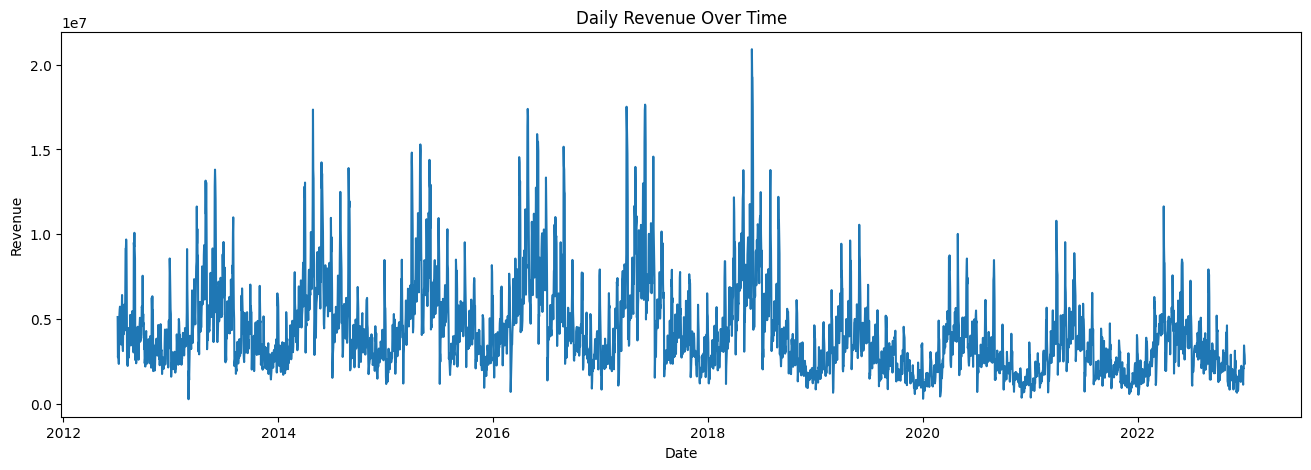

In [ ]:
# Vẽ chuỗi thời gian của revenue:
plt.figure(figsize=(16, 5))
plt.plot(plot_df['date'], plot_df['revenue'])
plt.title('Daily Revenue Over Time')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.show()
# Biểu đồ này để check nhìn xu hướng tổng thể của doanh thu theo thời gian và xem có pattern mùa vụ rõ không.

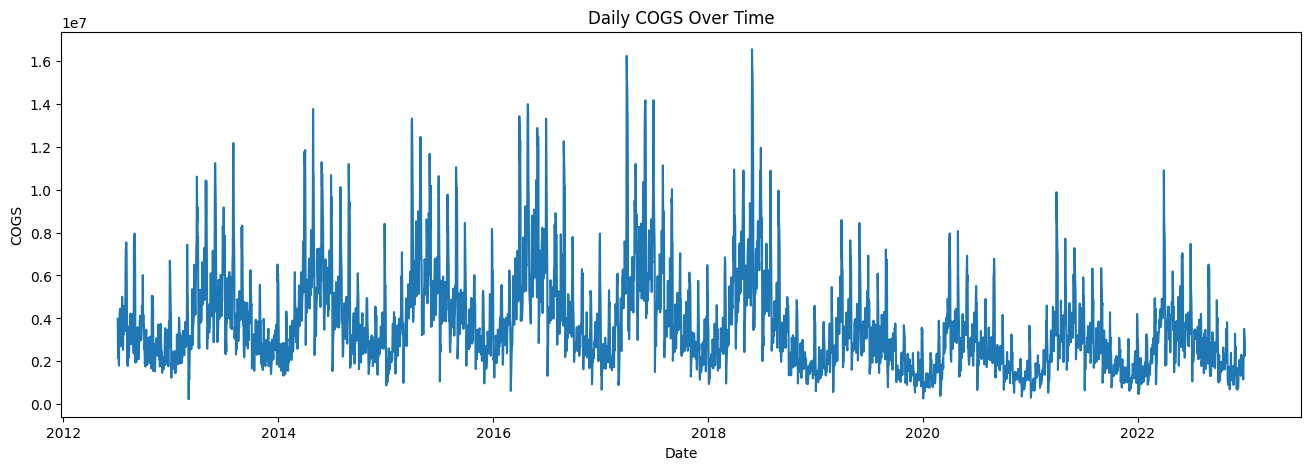

In [ ]:
# Vẽ chuỗi thời gian của COGS:
plt.figure(figsize=(16, 5))
plt.plot(plot_df['date'], plot_df['cogs'])
plt.title('Daily COGS Over Time')
plt.xlabel('Date')
plt.ylabel('COGS')
plt.show()
# Biểu đồ này giúp check xem giá vốn có đi cùng xu hướng với doanh thu hay không.

* Dùng moving average để làm mượt dữ liệu*

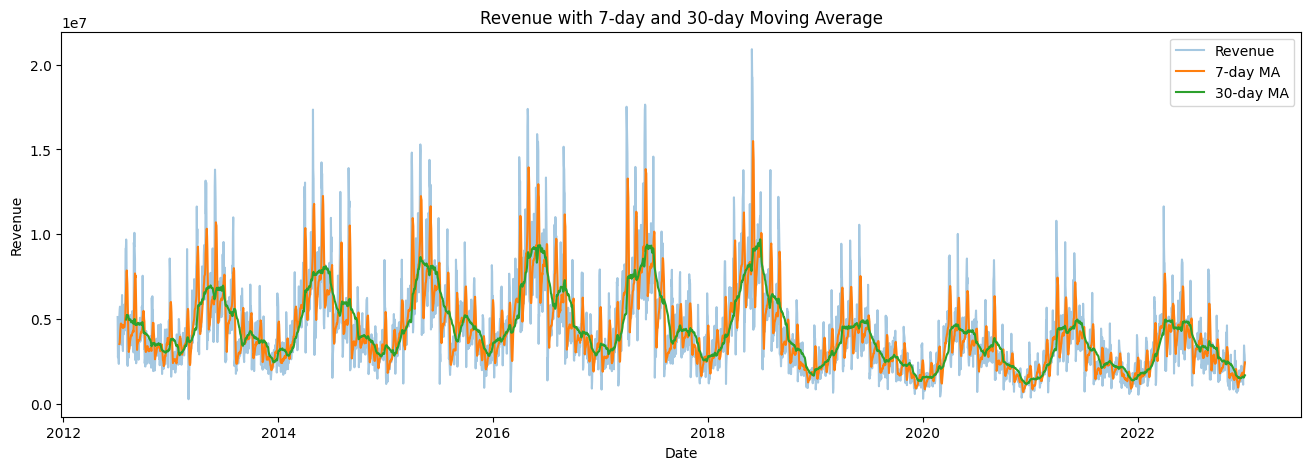

In [ ]:
plot_df['revenue_ma7'] = plot_df['revenue'].rolling(7).mean()
plot_df['revenue_ma30'] = plot_df['revenue'].rolling(30).mean()

plt.figure(figsize=(16, 5))
plt.plot(plot_df['date'], plot_df['revenue'], alpha=0.4, label='Revenue')
plt.plot(plot_df['date'], plot_df['revenue_ma7'], label='7-day MA')
plt.plot(plot_df['date'], plot_df['revenue_ma30'], label='30-day MA')
plt.title('Revenue with 7-day and 30-day Moving Average')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.legend()
plt.show()
# làm mượt chuỗi để nhìn rõ xu hướng ngắn hạn và dài hạn hơn, đặc biệt useful cho daily data.

In [ ]:
# Tạo feature ngày trong tuần và xem seasonality tuần
plot_df['day_of_week'] = plot_df['date'].dt.day_name()

dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
revenue_dow = plot_df.groupby('day_of_week')['revenue'].mean().reindex(dow_order)
cogs_dow = plot_df.groupby('day_of_week')['cogs'].mean().reindex(dow_order)

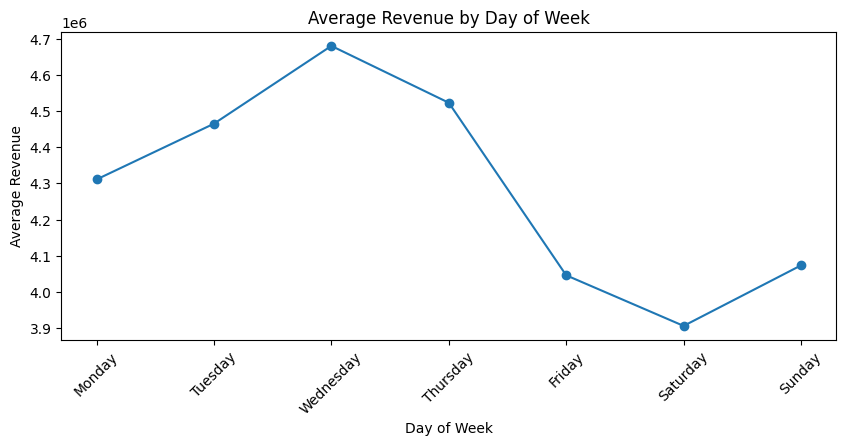

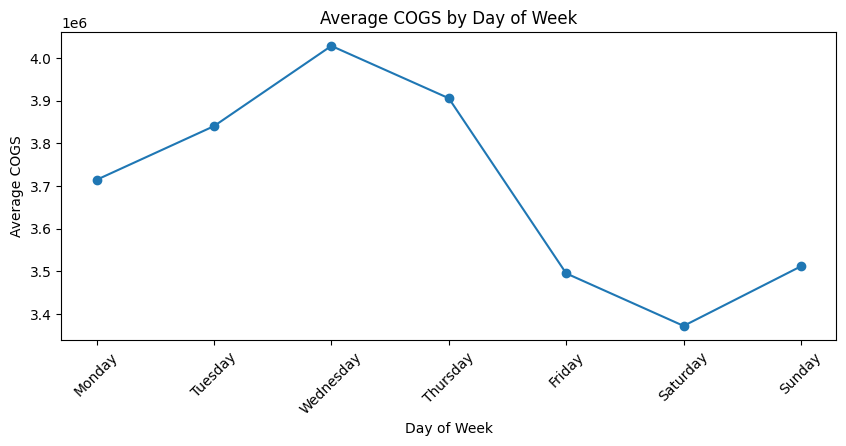

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(revenue_dow.index, revenue_dow.values, marker='o')
plt.title('Average Revenue by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Revenue')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(cogs_dow.index, cogs_dow.values, marker='o')
plt.title('Average COGS by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average COGS')
plt.xticks(rotation=45)
plt.show()

Có trend theo tuần


In [ ]:
# Tạo feature tháng để nhìn pattern theo năm
plot_df['month'] = plot_df['date'].dt.month

revenue_month = plot_df.groupby('month')['revenue'].mean()
cogs_month = plot_df.groupby('month')['cogs'].mean()

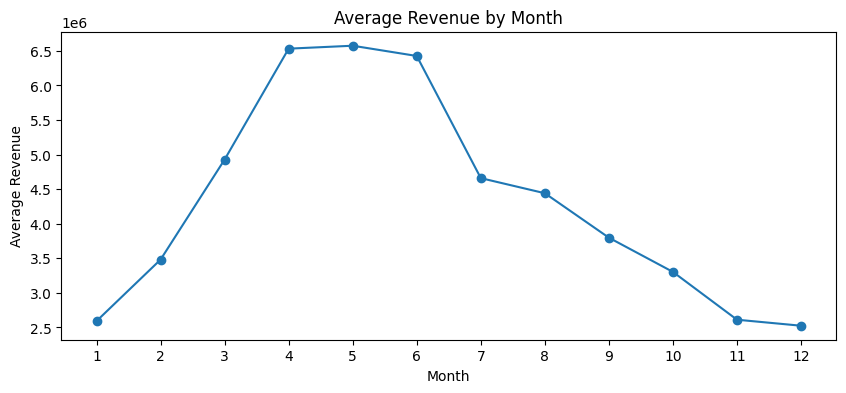

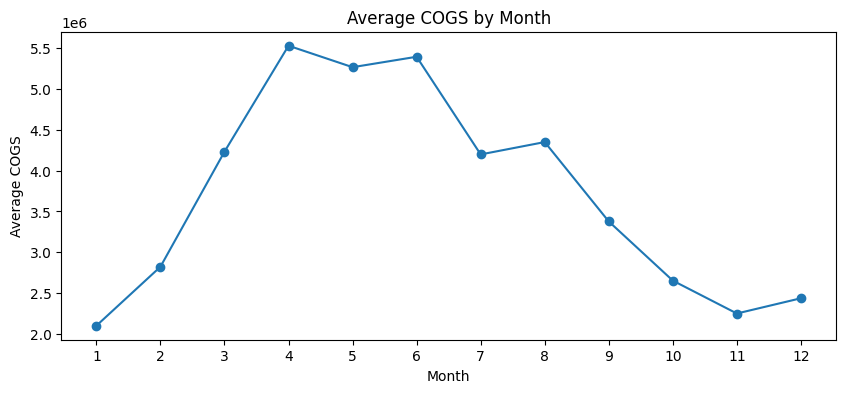

In [ ]:
# plot trung bình theo tháng
plt.figure(figsize=(10, 4))
plt.plot(revenue_month.index, revenue_month.values, marker='o')
plt.title('Average Revenue by Month')
plt.xlabel('Month')
plt.ylabel('Average Revenue')
plt.xticks(range(1, 13))
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(cogs_month.index, cogs_month.values, marker='o')
plt.title('Average COGS by Month')
plt.xlabel('Month')
plt.ylabel('Average COGS')
plt.xticks(range(1, 13))
plt.show()

*Hai biểu đồ này giúp check xem có annual seasonality không, từ đó cân nhắc Fourier terms hoặc seasonal features theo năm*

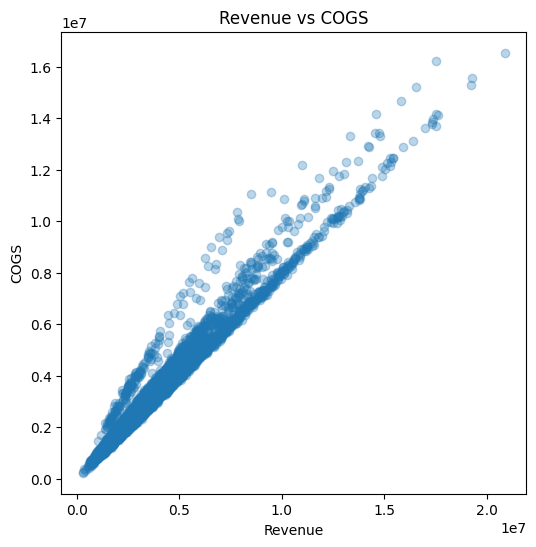

Correlation: 0.9759936393153099


In [ ]:
# Check tương quan giữa Revenue và COGS
plt.figure(figsize=(6, 6))
plt.scatter(plot_df['revenue'], plot_df['cogs'], alpha=0.3)
plt.title('Revenue vs COGS')
plt.xlabel('Revenue')
plt.ylabel('COGS')
plt.show()

print("Correlation:", plot_df[['revenue', 'cogs']].corr().iloc[0, 1])

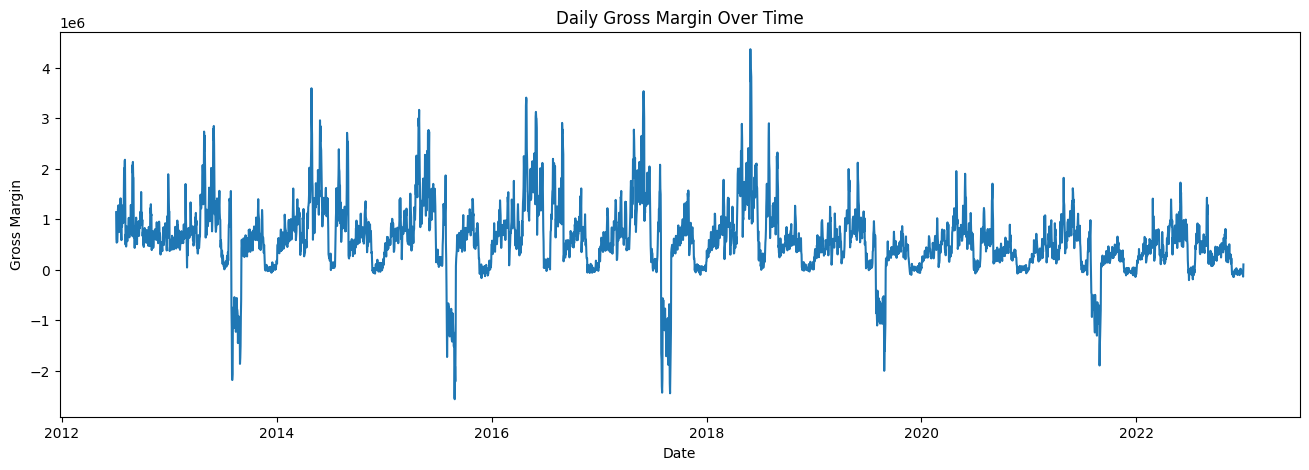

In [ ]:
# margin để hiểu business dynamics
plot_df['gross_margin'] = plot_df['revenue'] - plot_df['cogs']

plt.figure(figsize=(16, 5))
plt.plot(plot_df['date'], plot_df['gross_margin'])
plt.title('Daily Gross Margin Over Time')
plt.xlabel('Date')
plt.ylabel('Gross Margin')
plt.show()

*Margin giúp bạn nhìn thêm chất lượng doanh thu theo thời gian, đôi khi rất hữu ích để giải thích behavior của revenue và cogs.*


# Quick summary:
weekly seasonality rõ

annual/monthly seasonality rõ

correlation rất mạnh giữa Revenue và COGS

# Baseline model:

In [ ]:
# Tạo train/validation set:
forecast_horizon = len(sample_submission) # dùng 548 ngày cuối để làm horizon của sample submission

train_df = ts_model_df.iloc[:-forecast_horizon].copy()
valid_df = ts_model_df.iloc[-forecast_horizon:].copy()

In [ ]:
# đưa date về cộtđể xử lý feature ngày trong tuần
train_base = train_df.reset_index().copy()
valid_base = valid_df.reset_index().copy()

In [ ]:
# Tạo feature day of week
train_base['day_of_week'] = train_base['date'].dt.day_name()
valid_base['day_of_week'] = valid_base['date'].dt.day_name()

In [ ]:
# Tính baseline trung bình theo ngày trong tuần từ tập train:
dow_baseline = train_base.groupby('day_of_week')[['revenue', 'cogs']].mean().reset_index()
display(dow_baseline)

,day_of_week,revenue,cogs
0,Friday,4.276990e+06,3.671369e+06
1,Monday,4.547845e+06,3.896608e+06
2,Saturday,4.117510e+06,3.536417e+06
3,Sunday,4.290145e+06,3.676419e+06
4,Thursday,4.775167e+06,4.100710e+06
5,Tuesday,4.708351e+06,4.027098e+06
6,Wednesday,4.936730e+06,4.227016e+06


In [ ]:
# Tạo dự báo baseline cho validation set :
valid_pred = valid_base[['date', 'day_of_week', 'revenue', 'cogs']].merge(
    dow_baseline,
    on='day_of_week',
    how='left',
    suffixes=('_actual', '_pred')
)

display(valid_pred.head())

,date,day_of_week,revenue_actual,cogs_actual,revenue_pred,cogs_pred
0,2021-07-02,Friday,4397949.68,4326458.07,4.276990e+06,3.671369e+06
1,2021-07-03,Saturday,3132513.38,3101143.37,4.117510e+06,3.536417e+06
2,2021-07-04,Sunday,730601.15,647312.84,4.290145e+06,3.676419e+06
3,2021-07-05,Monday,1878817.85,1927429.12,4.547845e+06,3.896608e+06
4,2021-07-06,Tuesday,1616214.16,1626948.22,4.708351e+06,4.027098e+06


In [ ]:
# hàm tính metric evaluate
def evaluate_forecast(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return mae, rmse

In [ ]:
# đánh giá baseline của revenue:
revenue_mae, revenue_rmse = evaluate_forecast(
    valid_pred['revenue_actual'],
    valid_pred['revenue_pred']
)

print("Revenue baseline MAE:", revenue_mae)
print("Revenue baseline RMSE:", revenue_rmse)

Revenue baseline MAE: 1990254.5123587686
Revenue baseline RMSE: 2259350.33629199


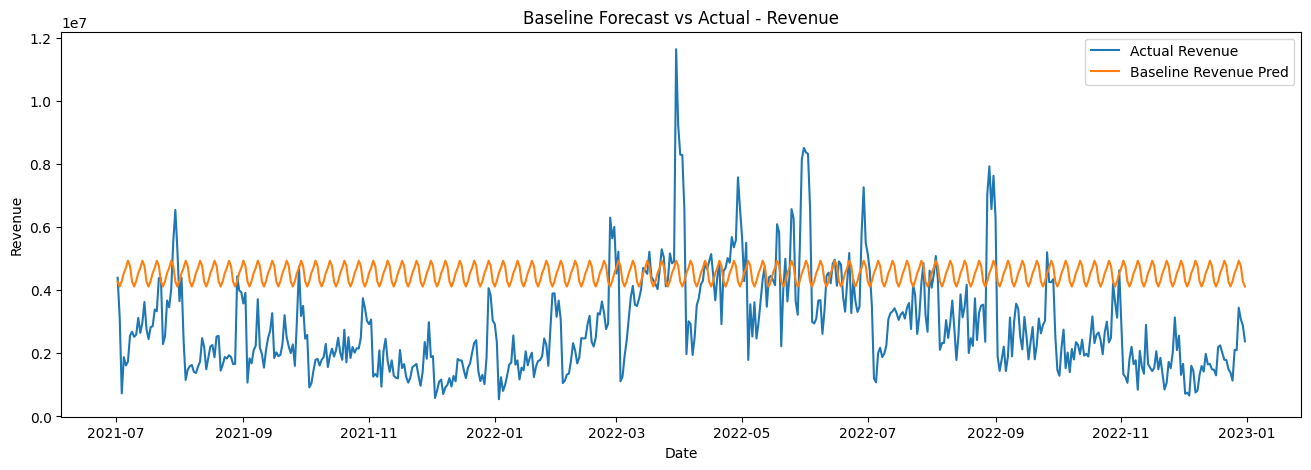

In [ ]:
plt.figure(figsize=(16, 5))
plt.plot(valid_pred['date'], valid_pred['revenue_actual'], label='Actual Revenue')
plt.plot(valid_pred['date'], valid_pred['revenue_pred'], label='Baseline Revenue Pred')
plt.title('Baseline Forecast vs Actual - Revenue')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.legend()
plt.show()

In [ ]:
# đánh giá baseline cho COGS:
cogs_mae, cogs_rmse = evaluate_forecast(
    valid_pred['cogs_actual'],
    valid_pred['cogs_pred']
)

print("COGS baseline MAE:", cogs_mae)
print("COGS baseline RMSE:", cogs_rmse)

COGS baseline MAE: 1617745.6680747652
COGS baseline RMSE: 1861762.9456908074


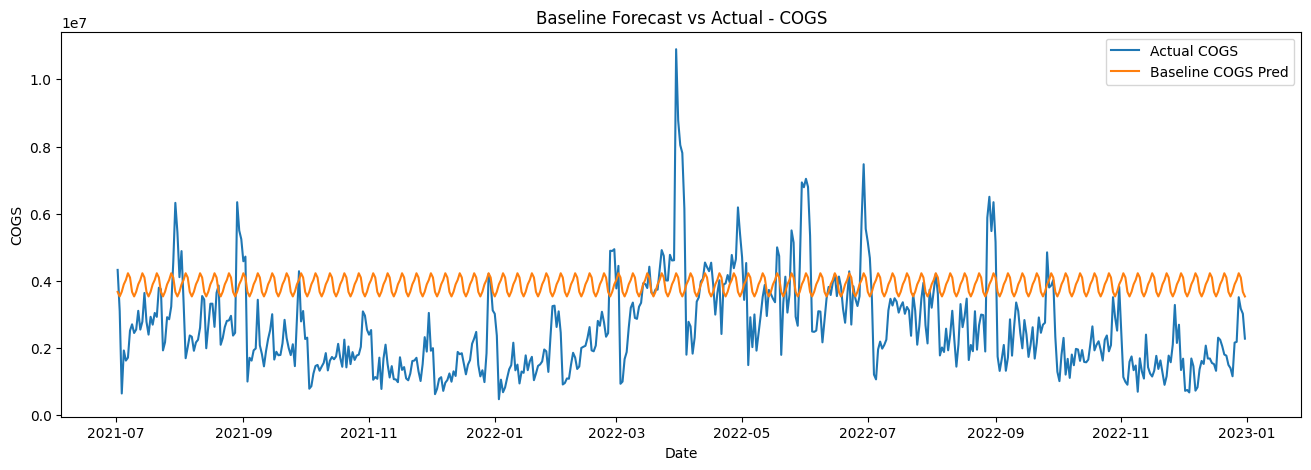

In [ ]:
plt.figure(figsize=(16, 5))
plt.plot(valid_pred['date'], valid_pred['cogs_actual'], label='Actual COGS')
plt.plot(valid_pred['date'], valid_pred['cogs_pred'], label='Baseline COGS Pred')
plt.title('Baseline Forecast vs Actual - COGS')
plt.xlabel('Date')
plt.ylabel('COGS')
plt.legend()
plt.show()

In [ ]:
# lưu kết quả:
baseline_results = {
    'revenue_mae': revenue_mae,
    'revenue_rmse': revenue_rmse,
    'cogs_mae': cogs_mae,
    'cogs_rmse': cogs_rmse
}

baseline_results

{'revenue_mae': 1990254.5123587686,
 'revenue_rmse': np.float64(2259350.33629199),
 'cogs_mae': 1617745.6680747652,
 'cogs_rmse': np.float64(1861762.9456908074)}

# Tạo exogenous features cho SARIMAX:

In [ ]:
# Tạo 2 bảng nguồn: một bảng lịch sử để train model và một bảng future dates để tạo exog cho giai đoạn forecast.
sarimax_base_df = ts_model_df.reset_index().copy()
future_df = sample_submission[['date']].copy()

In [ ]:
# Chuẩn hóa kiểu dữ liệu của cột date
sarimax_base_df['date'] = pd.to_datetime(sarimax_base_df['date'])
future_df['date'] = pd.to_datetime(future_df['date'])

#Hàm sinh calendar features + Fourier terms

In [ ]:
def make_date_exog(df, date_col='date', origin_date=None, fourier_order=3):
    exog = df[[date_col]].copy()

    exog['day_of_week'] = exog[date_col].dt.dayofweek
    exog['month'] = exog[date_col].dt.month
    exog['quarter'] = exog[date_col].dt.quarter

    exog['is_weekend'] = (exog[date_col].dt.dayofweek >= 5).astype(int)
    exog['is_month_start'] = exog[date_col].dt.is_month_start.astype(int)
    exog['is_month_end'] = exog[date_col].dt.is_month_end.astype(int)
    exog['is_quarter_start'] = exog[date_col].dt.is_quarter_start.astype(int)
    exog['is_quarter_end'] = exog[date_col].dt.is_quarter_end.astype(int)

    exog['dow_sin'] = np.sin(2 * np.pi * exog['day_of_week'] / 7)
    exog['dow_cos'] = np.cos(2 * np.pi * exog['day_of_week'] / 7)

    exog['month_sin'] = np.sin(2 * np.pi * exog['month'] / 12)
    exog['month_cos'] = np.cos(2 * np.pi * exog['month'] / 12)

    if origin_date is None:
        origin_date = exog[date_col].min()

    t = (exog[date_col] - origin_date).dt.days

    for k in range(1, fourier_order + 1):
        exog[f'fourier_sin_{k}'] = np.sin(2 * np.pi * k * t / 365.25)
        exog[f'fourier_cos_{k}'] = np.cos(2 * np.pi * k * t / 365.25)

    return exog

In [ ]:
# Chọn mốc thời gian bắt đầu để tính fourier liên tục:
origin_date = sarimax_base_df['date'].min()

In [ ]:
# Tạo exogenous features cho dữ liệu lịch sử
exog_train_full = make_date_exog(
    sarimax_base_df,
    date_col='date',
    origin_date=origin_date,
    fourier_order=3
)

In [ ]:
# Tạo exogenous features cho future horizon
exog_future = make_date_exog(
    future_df,
    date_col='date',
    origin_date=origin_date,
    fourier_order=3
)

In [ ]:
# Bỏ cột date, chỉ giữ ma trận exog số
X_train_full = exog_train_full.drop(columns=['date']).copy()
X_future = exog_future.drop(columns=['date']).copy()
# SARIMAX cần ma trận exogenous dạng số, nên ở đây bỏ cột ngày và giữ lại toàn bộ feature số.

In [ ]:
# Đặt lại index để khớp với time series chính:
X_train_full.index = ts_model_df.index
X_future.index = future_df['date']

In [ ]:
# Tạo target riếng cho revenue và COGS:
y_revenue = ts_model_df['revenue'].copy()
y_cogs = ts_model_df['cogs'].copy()

In [ ]:
# LOG transform để chuẩn bị modelling:
y_revenue_log = np.log1p(y_revenue)
y_cogs_log = np.log1p(y_cogs)

In [ ]:
# Quick check output
display(X_train_full.head())
display(X_future.head())

print("X_train_full shape:", X_train_full.shape)
print("X_future shape:", X_future.shape)
print("y_revenue_log shape:", y_revenue_log.shape)
print("y_cogs_log shape:", y_cogs_log.shape)

,day_of_week,month,quarter,is_weekend,is_month_start,is_month_end,is_quarter_start,is_quarter_end,dow_sin,dow_cos,month_sin,month_cos,fourier_sin_1,fourier_cos_1,fourier_sin_2,fourier_cos_2,fourier_sin_3,fourier_cos_3
date,,,,,,,,,,,,,,,,,,
2012-07-04,2,7,3,0,0,0,0,0,0.974928,-0.222521,-0.5,-0.866025,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000
2012-07-05,3,7,3,0,0,0,0,0,0.433884,-0.900969,-0.5,-0.866025,0.017202,0.999852,0.034398,0.999408,0.051584,0.998669
2012-07-06,4,7,3,0,0,0,0,0,-0.433884,-0.900969,-0.5,-0.866025,0.034398,0.999408,0.068755,0.997634,0.103031,0.994678
2012-07-07,5,7,3,1,0,0,0,0,-0.974928,-0.222521,-0.5,-0.866025,0.051584,0.998669,0.103031,0.994678,0.154204,0.988039
2012-07-08,6,7,3,1,0,0,0,0,-0.781831,0.623490,-0.5,-0.866025,0.068755,0.997634,0.137185,0.990545,0.204966,0.978769


,day_of_week,month,quarter,is_weekend,is_month_start,is_month_end,is_quarter_start,is_quarter_end,dow_sin,dow_cos,month_sin,month_cos,fourier_sin_1,fourier_cos_1,fourier_sin_2,fourier_cos_2,fourier_sin_3,fourier_cos_3
date,,,,,,,,,,,,,,,,,,
2023-01-01,6,1,1,1,1,0,1,0,-0.781831,0.623490,0.5,0.866025,0.036547,-0.999332,-0.073045,0.997329,0.109446,-0.993993
2023-01-02,0,1,1,0,0,0,0,0,0.000000,1.000000,0.5,0.866025,0.019352,-0.999813,-0.038696,0.999251,0.058026,-0.998315
2023-01-03,1,1,1,0,0,0,0,0,0.781831,0.623490,0.5,0.866025,0.002150,-0.999998,-0.004301,0.999991,0.006451,-0.999979
2023-01-04,2,1,1,0,0,0,0,0,0.974928,-0.222521,0.5,0.866025,-0.015052,-0.999887,0.030100,0.999547,-0.045141,-0.998981
2023-01-05,3,1,1,0,0,0,0,0,0.433884,-0.900969,0.5,0.866025,-0.032249,-0.999480,0.064464,0.997920,-0.096613,-0.995322


X_train_full shape: (3833, 18)
X_future shape: (548, 18)
y_revenue_log shape: (3833,)
y_cogs_log shape: (3833,)


# Split dữ liệu và fit SARIMAX

In [ ]:
# Tạo validation horizon và split dữ liệu lịch sử

validation_horizon = len(sample_submission)

y_rev_train = y_revenue_log.iloc[:-validation_horizon]
y_rev_valid = y_revenue_log.iloc[-validation_horizon:]

y_cogs_train = y_cogs_log.iloc[:-validation_horizon]
y_cogs_valid = y_cogs_log.iloc[-validation_horizon:]

X_train = X_train_full.iloc[:-validation_horizon].copy()
X_valid = X_train_full.iloc[-validation_horizon:].copy()

In [ ]:
# Fit SARIMAX đầu tiên cho Revenue
revenue_model = SARIMAX(
    y_rev_train,
    exog=X_train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

revenue_result = revenue_model.fit(disp=False)

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
# Forecast Revenue trên validation:
revenue_valid_pred_log = revenue_result.forecast(
    steps=validation_horizon,
    exog=X_valid
)

revenue_valid_pred = np.expm1(revenue_valid_pred_log)
revenue_valid_actual = np.expm1(y_rev_valid)

In [ ]:
# Đánh giá Revenue SARIMAX
revenue_sarimax_mae, revenue_sarimax_rmse = evaluate_forecast(
    revenue_valid_actual,
    revenue_valid_pred
)

print("Revenue SARIMAX MAE:", revenue_sarimax_mae)
print("Revenue SARIMAX RMSE:", revenue_sarimax_rmse)

Revenue SARIMAX MAE: 903206.4569935327
Revenue SARIMAX RMSE: 1330411.1016837785


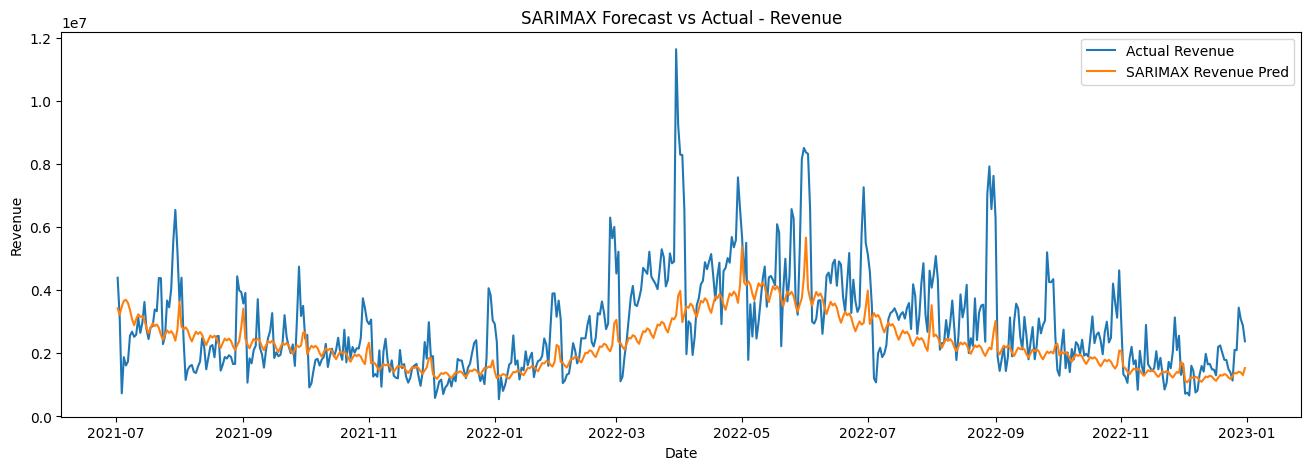

In [ ]:
# actual vs forecast cho Revenue:
plt.figure(figsize=(16, 5))
plt.plot(revenue_valid_actual.index, revenue_valid_actual.values, label='Actual Revenue')
plt.plot(revenue_valid_actual.index, revenue_valid_pred.values, label='SARIMAX Revenue Pred')
plt.title('SARIMAX Forecast vs Actual - Revenue')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.legend()
plt.show()

In [ ]:
# Fit SARIMAX đầu tiên cho COGS:
cogs_model = SARIMAX(
    y_cogs_train,
    exog=X_train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

cogs_result = cogs_model.fit(disp=False)

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
# Forecast COGS trên validation:
cogs_valid_pred_log = cogs_result.forecast(
    steps=validation_horizon,
    exog=X_valid
)

cogs_valid_pred = np.expm1(cogs_valid_pred_log)
cogs_valid_actual = np.expm1(y_cogs_valid)

In [ ]:
# Đánh giá COGS SARIMAX:
cogs_sarimax_mae, cogs_sarimax_rmse = evaluate_forecast(
    cogs_valid_actual,
    cogs_valid_pred
)

print("COGS SARIMAX MAE:", cogs_sarimax_mae)
print("COGS SARIMAX RMSE:", cogs_sarimax_rmse)

COGS SARIMAX MAE: 799999.7520183773
COGS SARIMAX RMSE: 1192495.9360020994


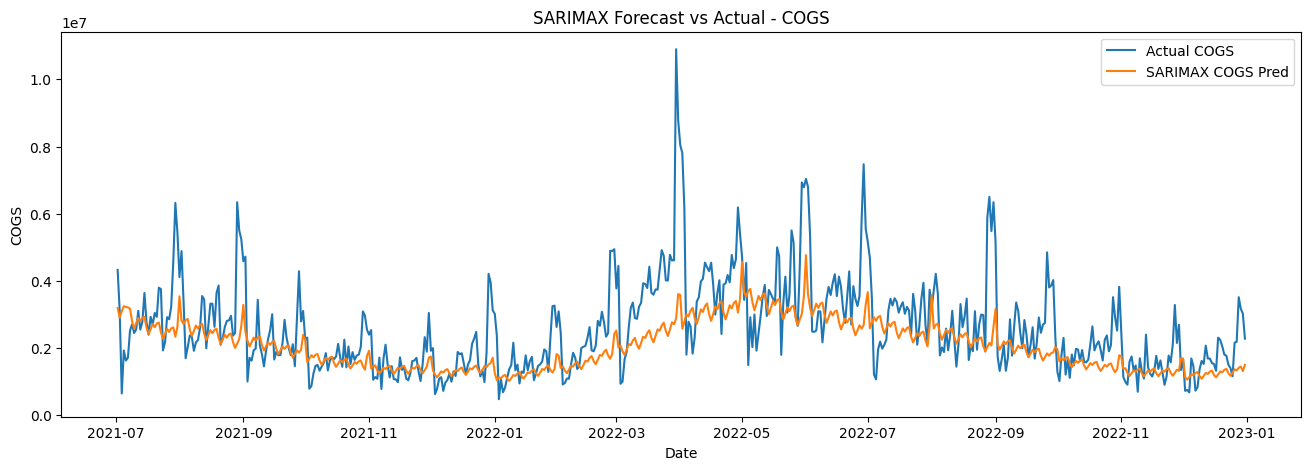

In [ ]:
# actual vs forecast cho COGS:
plt.figure(figsize=(16, 5))
plt.plot(cogs_valid_actual.index, cogs_valid_actual.values, label='Actual COGS')
plt.plot(cogs_valid_actual.index, cogs_valid_pred.values, label='SARIMAX COGS Pred')
plt.title('SARIMAX Forecast vs Actual - COGS')
plt.xlabel('Date')
plt.ylabel('COGS')
plt.legend()
plt.show()

In [ ]:
# lưu kết quả:
sarimax_results_v1 = {
    'revenue_mae': revenue_sarimax_mae,
    'revenue_rmse': revenue_sarimax_rmse,
    'cogs_mae': cogs_sarimax_mae,
    'cogs_rmse': cogs_sarimax_rmse
}

sarimax_results_v1

{'revenue_mae': 903206.4569935327,
 'revenue_rmse': np.float64(1330411.1016837785),
 'cogs_mae': 799999.7520183773,
 'cogs_rmse': np.float64(1192495.9360020994)}

In [ ]:
# So sánh nhanh:
print("=== Revenue ===")
print("Baseline MAE :", baseline_results['revenue_mae'])
print("SARIMAX  MAE :", sarimax_results_v1['revenue_mae'])
print("Baseline RMSE:", baseline_results['revenue_rmse'])
print("SARIMAX  RMSE:", sarimax_results_v1['revenue_rmse'])

print("\n=== COGS ===")
print("Baseline MAE :", baseline_results['cogs_mae'])
print("SARIMAX  MAE :", sarimax_results_v1['cogs_mae'])
print("Baseline RMSE:", baseline_results['cogs_rmse'])
print("SARIMAX  RMSE:", sarimax_results_v1['cogs_rmse'])

=== Revenue ===
Baseline MAE : 1990254.5123587686
SARIMAX  MAE : 903206.4569935327
Baseline RMSE: 2259350.33629199
SARIMAX  RMSE: 1330411.1016837785

=== COGS ===
Baseline MAE : 1617745.6680747652
SARIMAX  MAE : 799999.7520183773
Baseline RMSE: 1861762.9456908074
SARIMAX  RMSE: 1192495.9360020994


# Fine-tunning

In [ ]:
# Fine-tuning setup: tạo lại train/validation split for SARIMAX
validation_horizon = len(sample_submission)

y_rev_train = y_revenue_log.iloc[:-validation_horizon]
y_rev_valid = y_revenue_log.iloc[-validation_horizon:]

y_cogs_train = y_cogs_log.iloc[:-validation_horizon]
y_cogs_valid = y_cogs_log.iloc[-validation_horizon:]

X_train = X_train_full.iloc[:-validation_horizon].copy()
X_valid = X_train_full.iloc[-validation_horizon:].copy()

In [ ]:
# Fine-tuning search space for SARIMAX hyperparameters
tuning_orders = [
    (1, 1, 1),
    (2, 1, 1),
    (1, 1, 2),
    (2, 1, 2),
    (1, 0, 1)
]

tuning_seasonal_orders = [
    (1, 1, 1, 7),
    (1, 0, 1, 7),
    (0, 1, 1, 7),
    (1, 1, 0, 7)
]

In [ ]:
# Fine-tuning utility: run one SARIMAX hyperparameter configuration
def run_sarimax_tuning_experiment(y_train, y_valid, X_train, X_valid, order, seasonal_order):
    try:
        model = SARIMAX(
            y_train,
            exog=X_train,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        result = model.fit(disp=False)

        pred_log = result.forecast(steps=len(y_valid), exog=X_valid)
        pred = np.expm1(pred_log)
        actual = np.expm1(y_valid)

        mae, rmse = evaluate_forecast(actual, pred)

        return {
            'order': order,
            'seasonal_order': seasonal_order,
            'aic': result.aic,
            'mae': mae,
            'rmse': rmse,
            'status': 'ok'
        }

    except Exception as e:
        return {
            'order': order,
            'seasonal_order': seasonal_order,
            'aic': np.nan,
            'mae': np.nan,
            'rmse': np.nan,
            'status': f'fail: {str(e)[:120]}'
        }

In [ ]:
# Fine-tuning Revenue SARIMAX hyperparameters
revenue_tuning_results = []

for order in tuning_orders:
    for seasonal_order in tuning_seasonal_orders:
        print(f'Fine-tuning Revenue | order={order}, seasonal_order={seasonal_order}')

        res = run_sarimax_tuning_experiment(
            y_train=y_rev_train,
            y_valid=y_rev_valid,
            X_train=X_train,
            X_valid=X_valid,
            order=order,
            seasonal_order=seasonal_order
        )

        revenue_tuning_results.append(res)

Fine-tuning Revenue | order=(1, 1, 1), seasonal_order=(1, 1, 1, 7)


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Fine-tuning Revenue | order=(1, 1, 1), seasonal_order=(1, 0, 1, 7)


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Fine-tuning Revenue | order=(1, 1, 1), seasonal_order=(0, 1, 1, 7)


...

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Fine-tuning Revenue | order=(1, 0, 1), seasonal_order=(0, 1, 1, 7)


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Fine-tuning Revenue | order=(1, 0, 1), seasonal_order=(1, 1, 0, 7)


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
# Fine-tuning results summary for Revenue
revenue_tuning_df = pd.DataFrame(revenue_tuning_results)
revenue_tuning_df = revenue_tuning_df.sort_values(['rmse', 'mae'], ascending=True).reset_index(drop=True)

display(revenue_tuning_df)

,order,seasonal_order,aic,mae,rmse,status
0,"(1, 0, 1)","(0, 1, 1, 7)",906.389849,8.164731e+05,1.193061e+06,ok
1,"(2, 1, 2)","(1, 0, 1, 7)",837.442140,8.136416e+05,1.198316e+06,ok
2,"(1, 1, 1)","(1, 0, 1, 7)",834.315990,8.148315e+05,1.198617e+06,ok
3,"(1, 0, 1)","(1, 1, 1, 7)",891.158110,8.195476e+05,1.201874e+06,ok
4,"(1, 1, 2)","(1, 0, 1, 7)",839.818512,8.157725e+05,1.203315e+06,ok
5,"(2, 1, 1)","(1, 0, 1, 7)",829.965612,8.199962e+05,1.204709e+06,ok
6,"(1, 0, 1)","(1, 1, 0, 7)",1835.867222,8.572748e+05,1.231399e+06,ok
7,"(2, 1, 1)","(1, 1, 0, 7)",1843.985995,8.673792e+05,1.261209e+06,ok
8,"(1, 1, 1)","(0, 1, 1, 7)",923.286752,8.711380e+05,1.269610e+06,ok
9,"(2, 1, 2)","(0, 1, 1, 7)",922.225423,8.748264e+05,1.274094e+06,ok


In [ ]:
# Best fine-tuned SARIMAX configuration for Revenue
best_revenue_config = revenue_tuning_df.iloc[0].to_dict()
best_revenue_config

{'order': (1, 0, 1),
 'seasonal_order': (0, 1, 1, 7),
 'aic': 906.3898490695693,
 'mae': 816473.0579131979,
 'rmse': 1193060.646807696,
 'status': 'ok'}

In [ ]:
# Fine-tuning COGS SARIMAX hyperparameters
cogs_tuning_results = []

for order in tuning_orders:
    for seasonal_order in tuning_seasonal_orders:
        print(f'Fine-tuning COGS | order={order}, seasonal_order={seasonal_order}')

        res = run_sarimax_tuning_experiment(
            y_train=y_cogs_train,
            y_valid=y_cogs_valid,
            X_train=X_train,
            X_valid=X_valid,
            order=order,
            seasonal_order=seasonal_order
        )

        cogs_tuning_results.append(res)

Fine-tuning COGS | order=(1, 1, 1), seasonal_order=(1, 1, 1, 7)


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Fine-tuning COGS | order=(1, 1, 1), seasonal_order=(1, 0, 1, 7)


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Fine-tuning COGS | order=(1, 1, 1), seasonal_order=(0, 1, 1, 7)


...

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Fine-tuning COGS | order=(1, 0, 1), seasonal_order=(0, 1, 1, 7)


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Fine-tuning COGS | order=(1, 0, 1), seasonal_order=(1, 1, 0, 7)


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
# Fine-tuning COGS SARIMAX hyperparameters
cogs_tuning_results = []

for order in tuning_orders:
    for seasonal_order in tuning_seasonal_orders:
        print(f'Fine-tuning COGS | order={order}, seasonal_order={seasonal_order}')

        res = run_sarimax_tuning_experiment(
            y_train=y_cogs_train,
            y_valid=y_cogs_valid,
            X_train=X_train,
            X_valid=X_valid,
            order=order,
            seasonal_order=seasonal_order
        )

        cogs_tuning_results.append(res)

Fine-tuning COGS | order=(1, 1, 1), seasonal_order=(1, 1, 1, 7)


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Fine-tuning COGS | order=(1, 1, 1), seasonal_order=(1, 0, 1, 7)


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Fine-tuning COGS | order=(1, 1, 1), seasonal_order=(0, 1, 1, 7)


...

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Fine-tuning COGS | order=(1, 0, 1), seasonal_order=(0, 1, 1, 7)


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Fine-tuning COGS | order=(1, 0, 1), seasonal_order=(1, 1, 0, 7)


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
# Fine-tuning results summary for COGS
cogs_tuning_df = pd.DataFrame(cogs_tuning_results)
cogs_tuning_df = cogs_tuning_df.sort_values(['rmse', 'mae'], ascending=True).reset_index(drop=True)

display(cogs_tuning_df)

,order,seasonal_order,aic,mae,rmse,status
0,"(1, 0, 1)","(0, 1, 1, 7)",968.314475,7.346142e+05,1.090854e+06,ok
1,"(1, 1, 1)","(1, 0, 1, 7)",914.079431,7.364543e+05,1.096550e+06,ok
2,"(2, 1, 1)","(1, 0, 1, 7)",905.993387,7.376179e+05,1.099261e+06,ok
3,"(1, 1, 2)","(1, 0, 1, 7)",917.068970,7.365924e+05,1.099780e+06,ok
4,"(1, 0, 1)","(1, 1, 1, 7)",958.164690,7.415540e+05,1.101959e+06,ok
5,"(2, 1, 2)","(1, 0, 1, 7)",908.658613,7.407270e+05,1.106401e+06,ok
6,"(1, 0, 1)","(1, 1, 0, 7)",1924.824997,7.990441e+05,1.130089e+06,ok
7,"(1, 1, 2)","(1, 1, 0, 7)",1935.695291,7.967467e+05,1.144139e+06,ok
8,"(2, 1, 1)","(0, 1, 1, 7)",979.166447,7.730144e+05,1.146858e+06,ok
9,"(2, 1, 1)","(1, 1, 0, 7)",1932.892293,7.990522e+05,1.147997e+06,ok


In [ ]:
# Best fine-tuned SARIMAX configuration for COGS
best_cogs_config = cogs_tuning_df.iloc[0].to_dict()
best_cogs_config

{'order': (1, 0, 1),
 'seasonal_order': (0, 1, 1, 7),
 'aic': 968.3144749411658,
 'mae': 734614.2417490515,
 'rmse': 1090853.8207045542,
 'status': 'ok'}

In [ ]:
# Fine-tuning comparison: baseline vs initial SARIMAX vs tuned SARIMAX
print("=== REVENUE ===")
print("Baseline RMSE :", baseline_results['revenue_rmse'])
print("SARIMAX v1 RMSE:", sarimax_results_v1['revenue_rmse'])
print("Tuned SARIMAX RMSE:", best_revenue_config['rmse'])

print("\n=== COGS ===")
print("Baseline RMSE :", baseline_results['cogs_rmse'])
print("SARIMAX v1 RMSE:", sarimax_results_v1['cogs_rmse'])
print("Tuned SARIMAX RMSE:", best_cogs_config['rmse'])

=== REVENUE ===
Baseline RMSE : 2259350.33629199
SARIMAX v1 RMSE: 1330411.1016837785
Tuned SARIMAX RMSE: 1193060.646807696

=== COGS ===
Baseline RMSE : 1861762.9456908074
SARIMAX v1 RMSE: 1192495.9360020994
Tuned SARIMAX RMSE: 1090853.8207045542


In [ ]:
# Save best fine-tuned hyperparameters for final refit
best_finetuned_configs = {
    'revenue': {
        'order': best_revenue_config['order'],
        'seasonal_order': best_revenue_config['seasonal_order']
    },
    'cogs': {
        'order': best_cogs_config['order'],
        'seasonal_order': best_cogs_config['seasonal_order']
    }
}

best_finetuned_configs

{'revenue': {'order': (1, 0, 1), 'seasonal_order': (0, 1, 1, 7)},
 'cogs': {'order': (1, 0, 1), 'seasonal_order': (0, 1, 1, 7)}}

# Refit best fine-tunning SARIMAX model


In [ ]:
# Refit setup: load best fine-tuned SARIMAX hyperparameters
best_revenue_order = best_finetuned_configs['revenue']['order']
best_revenue_seasonal = best_finetuned_configs['revenue']['seasonal_order']

best_cogs_order = best_finetuned_configs['cogs']['order']
best_cogs_seasonal = best_finetuned_configs['cogs']['seasonal_order']

print("Best Revenue config:", best_revenue_order, best_revenue_seasonal)
print("Best COGS config:", best_cogs_order, best_cogs_seasonal)

Best Revenue config: (1, 0, 1) (0, 1, 1, 7)
Best COGS config: (1, 0, 1) (0, 1, 1, 7)


In [ ]:
# Refit best fine-tuned SARIMAX for Revenue on full historical data
from statsmodels.tsa.statespace.sarimax import SARIMAX

final_revenue_model = SARIMAX(
    y_revenue_log,
    exog=X_train_full,
    order=best_revenue_order,
    seasonal_order=best_revenue_seasonal,
    enforce_stationarity=False,
    enforce_invertibility=False
)

final_revenue_result = final_revenue_model.fit(disp=False)

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
# Refit best fine-tuned SARIMAX for COGS on full historical data
final_cogs_model = SARIMAX(
    y_cogs_log,
    exog=X_train_full,
    order=best_cogs_order,
    seasonal_order=best_cogs_seasonal,
    enforce_stationarity=False,
    enforce_invertibility=False
)

final_cogs_result = final_cogs_model.fit(disp=False)

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
# Forecast future horizon for Revenue
future_revenue_pred_log = final_revenue_result.forecast(
    steps=len(X_future),
    exog=X_future
)

In [ ]:
# Forecast future horizon for COGS
future_cogs_pred_log = final_cogs_result.forecast(
    steps=len(X_future),
    exog=X_future
)

In [ ]:
# Inverse transform predictions back to original scale
future_revenue_pred = np.expm1(future_revenue_pred_log)
future_cogs_pred = np.expm1(future_cogs_pred_log)

In [ ]:
# post-processing: clip negative predictions to zero
future_revenue_pred = np.clip(future_revenue_pred, 0, None)
future_cogs_pred = np.clip(future_cogs_pred, 0, None)

In [ ]:
# Create submission dataframe using sample submission format
submission_df = sample_submission.copy()
submission_df['revenue'] = future_revenue_pred.values
submission_df['cogs'] = future_cogs_pred.values

display(submission_df.head())
display(submission_df.tail())
print(submission_df.shape)

,date,revenue,cogs
0,2023-01-01,2.266691e+06,2.007579e+06
1,2023-01-02,1.924467e+06,1.614005e+06
2,2023-01-03,1.749480e+06,1.480650e+06
3,2023-01-04,1.546556e+06,1.310605e+06
4,2023-01-05,1.683210e+06,1.421374e+06


,date,revenue,cogs
543,2024-06-27,3.836390e+06,3.350976e+06
544,2024-06-28,3.312323e+06,2.919386e+06
545,2024-06-29,3.209575e+06,2.826137e+06
546,2024-06-30,4.075057e+06,3.657084e+06
547,2024-07-01,5.239027e+06,4.870465e+06


(548, 3)


In [ ]:
# Sanity check for submission output
print("Revenue min prediction:", submission_df['revenue'].min())
print("Revenue max prediction:", submission_df['revenue'].max())
print("COGS min prediction:", submission_df['cogs'].min())
print("COGS max prediction:", submission_df['cogs'].max())
print("Any missing in submission:", submission_df.isnull().sum().sum())

Revenue min prediction: 1394070.074807826
Revenue max prediction: 7080137.897905106
COGS min prediction: 1186980.3752547153
COGS max prediction: 5999933.405663667
Any missing in submission: 0


In [ ]:
# Business sanity check: compare COGS and Revenue predictions
print("Number of days where COGS > Revenue:", (submission_df['cogs'] > submission_df['revenue']).sum())

Number of days where COGS > Revenue: 23


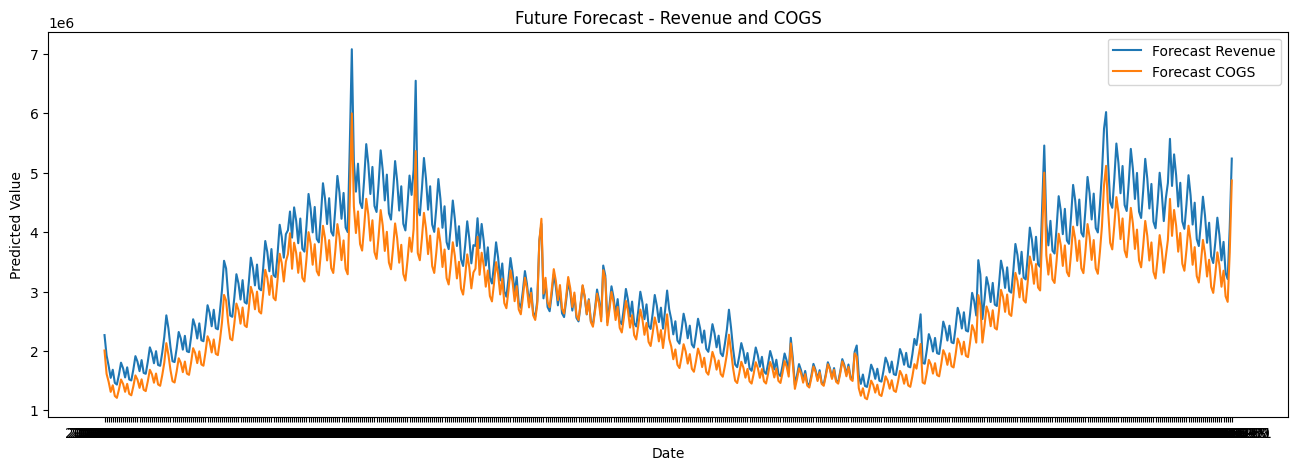

In [ ]:
# visualization: inspect future forecast curves
plt.figure(figsize=(16, 5))
plt.plot(submission_df['date'], submission_df['revenue'], label='Forecast Revenue')
plt.plot(submission_df['date'], submission_df['cogs'], label='Forecast COGS')
plt.title('Future Forecast - Revenue and COGS')
plt.xlabel('Date')
plt.ylabel('Predicted Value')
plt.legend()
plt.show()

In [ ]:
# Match exact column names required by Kaggle sample submission
submission_df = submission_df.rename(columns={
    'date': 'Date',
    'revenue': 'Revenue',
    'cogs': 'COGS'
})

display(submission_df.head())
print(submission_df.columns.tolist())

,Date,Revenue,COGS
0,2023-01-01,2.266691e+06,2.007579e+06
1,2023-01-02,1.924467e+06,1.614005e+06
2,2023-01-03,1.749480e+06,1.480650e+06
3,2023-01-04,1.546556e+06,1.310605e+06
4,2023-01-05,1.683210e+06,1.421374e+06


['Date', 'Revenue', 'COGS']


In [ ]:
# Export corrected submission file
submission_df.to_csv('submission_fixed.csv', index=False)
print("Saved file: submission_fixed.csv")

Saved file: submission_fixed.csv
